# 🚀 Análise Estatística — Missões Espaciais (1957–2020)
**Global Solution | Estatística e Análise de Dados**

**Base:** All Space Missions from 1957 — Kaggle  
**Arquivo:** `Space_Corrected.csv`  

---
## Estrutura do Notebook
- **Etapa 1** — Escolha e justificativa da base de dados
- **Etapa 2** — Tabelas de distribuição de frequências
- **Etapa 3** — Gráficos estatísticos
- **Etapa 4** — Estatística descritiva (análises univariadas)
- **Etapa 5** — Conclusões e insights
---

## Importações

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo global dos gráficos
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.facecolor'  : '#F7F9FC',
    'axes.facecolor'    : '#F7F9FC',
})

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


---
# ETAPA 1 — Escolha e Justificativa da Base de Dados
> **Valor: 2,0 pontos**

## 1.1 Nome da Base
**All Space Missions from 1957**

## 1.2 Fonte
**Plataforma:** Kaggle  
**Link:** https://www.kaggle.com/datasets/agirlcoding/all-space-missions-from-1957  
**Arquivo:** `Space_Corrected.csv`

## 1.3 Justificativa

**Por que essa base foi escolhida?**  
O dataset reúne todos os lançamentos espaciais registrados desde o Sputnik (1957) até 2020, cobrindo 63 anos de exploração espacial. Os dados são reais, coletados de registros históricos oficiais de agências e empresas, sem geração artificial.

**Qual a relação com o projeto?**  
O tema da Global Solution é a Nova Economia Espacial. Esta base permite analisar diretamente: evolução histórica dos lançamentos, custos operacionais, taxa de sucesso das missões e os principais players do mercado — informações estratégicas para qualquer empresa que deseje atuar no setor espacial.

**Quantos registros possui?**  
**4.324 lançamentos espaciais**, cobrindo o período de 1957 a 2020.

**Quais variáveis serão analisadas?**

| Variável | Tipo | Descrição |
|---|---|---|
| `ano` | Quantitativa Discreta | Ano do lançamento (1957–2020) |
| `custo_milhoes` | Quantitativa Contínua | Custo do foguete em milhões de USD |
| `empresa` | Qualitativa Nominal | Operadora responsável pelo lançamento |
| `status_missao` | Qualitativa Nominal | Resultado da missão (Success/Failure) |
| `pais` | Qualitativa Nominal | País de lançamento |

In [4]:
# ── Carregamento e limpeza ─────────────────────────────────────────────────
df = pd.read_csv('Space_Corrected.csv')

df.rename(columns={
    'Company Name'  : 'empresa',
    'Location'      : 'local',
    'Datum'         : 'data',
    'Detail'        : 'detalhe',
    'Status Rocket' : 'status_foguete',
    ' Rocket'       : 'custo_raw',
    'Status Mission': 'status_missao'
}, inplace=True)

# Extrair ano
df['ano'] = pd.to_datetime(df['data'], errors='coerce').dt.year.astype('Int64')

# Limpar custo em milhões USD
df['custo_milhoes'] = pd.to_numeric(
    df['custo_raw'].astype(str).str.strip(), errors='coerce'
)

# Extrair país (último elemento do campo Location)
df['pais'] = df['local'].str.split(',').str[-1].str.strip()

# Resumo
print('=' * 55)
print('  VISÃO GERAL DO DATASET')
print('=' * 55)
print(f'  Total de registros       : {len(df):,}')
print(f'  Período coberto          : {df["ano"].min()} – {df["ano"].max()}')
print(f'  Empresas/agências únicas : {df["empresa"].nunique()}')
print(f'  Países de lançamento     : {df["pais"].nunique()}')
print(f'  Missões com custo inform.: {df["custo_milhoes"].notna().sum():,}')
print(f'  Taxa de sucesso global   : {(df["status_missao"]=="Success").mean()*100:.1f}%')
print('=' * 55)
df.head()

  VISÃO GERAL DO DATASET
  Total de registros       : 4,324
  Período coberto          : 1957 – 2020
  Empresas/agências únicas : 56
  Países de lançamento     : 22
  Missões com custo inform.: 949
  Taxa de sucesso global   : 89.7%


,Unnamed: 0.1,Unnamed: 0,empresa,local,data,detalhe,status_foguete,custo_raw,status_missao,ano,custo_milhoes,pais
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,2020,50.00,USA
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,2020,29.75,China
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,2020,NaN,USA
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,2020,65.00,Kazakhstan
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success,2020,145.00,USA


---
# ETAPA 2 — Tabelas de Distribuição de Frequências
> **Valor: 2,0 pontos**

## 2.1 Variável Quantitativa DISCRETA
**Variável:** Número de lançamentos por ano  
**Justificativa:** A contagem de missões por ano é um número inteiro — característica fundamental de variável discreta. Agrupamos os anos em períodos históricos para facilitar a leitura e interpretação.

In [5]:
# Contagem de missões por ano → agrupadas em períodos históricos
bins   = [1957, 1960, 1970, 1980, 1990, 2000, 2010, 2021]
labels = ['1957–1959','1960–1969','1970–1979','1980–1989',
          '1990–1999','2000–2009','2010–2020']

df['periodo'] = pd.cut(df['ano'].astype(float),
                       bins=bins, labels=labels, right=False)

# Montar tabela
tab_disc = (
    df.groupby('periodo', observed=True)
      .size()
      .reset_index(name='Freq. Absoluta')
)
tab_disc.rename(columns={'periodo': 'Período'}, inplace=True)
tab_disc['Freq. Relativa (%)'] = (
    tab_disc['Freq. Absoluta'] / tab_disc['Freq. Absoluta'].sum() * 100
).round(2)
tab_disc['Freq. Acumulada'] = tab_disc['Freq. Absoluta'].cumsum()
tab_disc['Fr. Rel. Acum. (%)'] = tab_disc['Freq. Relativa (%)'].cumsum().round(2)

# Linha de total
total_row = pd.DataFrame([[
    'TOTAL',
    tab_disc['Freq. Absoluta'].sum(),
    100.00,
    tab_disc['Freq. Acumulada'].iloc[-1],
    '—'
]], columns=tab_disc.columns)

tab_disc_final = pd.concat([tab_disc, total_row], ignore_index=True)

print('TABELA 1 — Distribuição de Frequências: Lançamentos por Período (Discreta)')
print('─' * 72)
tab_disc_final.style.set_caption('Lançamentos por Período Histórico')

TABELA 1 — Distribuição de Frequências: Lançamentos por Período (Discreta)
────────────────────────────────────────────────────────────────────────


,Período,Freq. Absoluta,Freq. Relativa (%),Freq. Acumulada,Fr. Rel. Acum. (%)
0,1957–1959,45,1.070000,45,1.070000
1,1960–1969,752,17.910000,797,18.980000
2,1970–1979,983,23.420000,1780,42.400000
3,1980–1989,607,14.460000,2387,56.860000
4,1990–1999,627,14.940000,3014,71.800000
5,2000–2009,464,11.050000,3478,82.850000
6,2010–2020,720,17.150000,4198,100.000000
7,TOTAL,4198,100.000000,4198,—


**📌 Interpretação:**  
A década de **1970–1979** concentrou o maior volume de lançamentos (**23,42%**), reflexo direto da corrida espacial entre EUA e União Soviética. Mais da metade de toda a atividade espacial da história (**56,86%**) ocorreu antes de 1990, período de domínio governamental. O período **2010–2020** apresenta retomada expressiva (**17,15%**), impulsionada pela entrada de empresas privadas como SpaceX e RocketLab.

## 2.2 Variável Quantitativa CONTÍNUA
**Variável:** Custo do foguete (em Milhões de USD)  
**Justificativa:** O custo é uma medida que pode assumir qualquer valor dentro de um intervalo — típica variável contínua. Foram definidas 7 classes para cobrir o intervalo completo de US$5,3M a US$450M.

In [6]:
# Distribuição de custo em classes
bins_c   = [0, 50, 100, 150, 200, 250, 350, 460]
labels_c = ['0–50','50–100','100–150','150–200','200–250','250–350','350–450']

df['classe_custo'] = pd.cut(
    df['custo_milhoes'], bins=bins_c, labels=labels_c, right=False
)

tab_cont = (
    df.groupby('classe_custo', observed=True)
      .size()
      .reset_index(name='Freq. Absoluta')
)
tab_cont = tab_cont[tab_cont['Freq. Absoluta'] > 0].copy()
tab_cont.rename(columns={'classe_custo': 'Classe (US$ M)'}, inplace=True)
tab_cont['Freq. Relativa (%)'] = (
    tab_cont['Freq. Absoluta'] / tab_cont['Freq. Absoluta'].sum() * 100
).round(2)
tab_cont['Freq. Acumulada'] = tab_cont['Freq. Absoluta'].cumsum()
tab_cont['Fr. Rel. Acum. (%)'] = tab_cont['Freq. Relativa (%)'].cumsum().round(2)

total_c = pd.DataFrame([[
    'TOTAL',
    tab_cont['Freq. Absoluta'].sum(),
    100.00,
    tab_cont['Freq. Acumulada'].iloc[-1],
    '—'
]], columns=tab_cont.columns)

tab_cont_final = pd.concat([tab_cont, total_c], ignore_index=True)

print('TABELA 2 — Distribuição de Frequências: Custo do Foguete em US$ Milhões (Contínua)')
print('─' * 72)
tab_cont_final.style.set_caption('Custo dos Foguetes por Classe (US$ Milhões)')

TABELA 2 — Distribuição de Frequências: Custo do Foguete em US$ Milhões (Contínua)
────────────────────────────────────────────────────────────────────────


,Classe (US$ M),Freq. Absoluta,Freq. Relativa (%),Freq. Acumulada,Fr. Rel. Acum. (%)
0,0–50,374,39.410000,374,39.410000
1,50–100,235,24.760000,609,64.170000
2,100–150,89,9.380000,698,73.550000
3,150–200,29,3.060000,727,76.610000
4,200–250,75,7.900000,802,84.510000
5,350–450,147,15.490000,949,100.000000
6,TOTAL,949,100.000000,949,—


**📌 Interpretação:**  
A distribuição é **bimodal**: **39,41%** das missões custaram menos de US$50M (foguetes de pequeno porte e missões soviéticas históricas) e **15,49%** se concentram na faixa US$350–450M (grandes foguetes como Ariane 5 e Delta IV Heavy). Apenas **10,96%** das missões ficaram na faixa intermediária de US$150–250M, revelando dois segmentos de mercado bem distintos: operações de baixo custo e missões de alto valor agregado.

---
# ETAPA 3 — Gráficos Estatísticos
> **Valor: 2,0 pontos**

## Gráfico 1 — Histograma: Distribuição do Custo dos Foguetes (US$ Milhões)
**Tipo:** Histograma  
**Variável:** Custo do foguete (contínua)

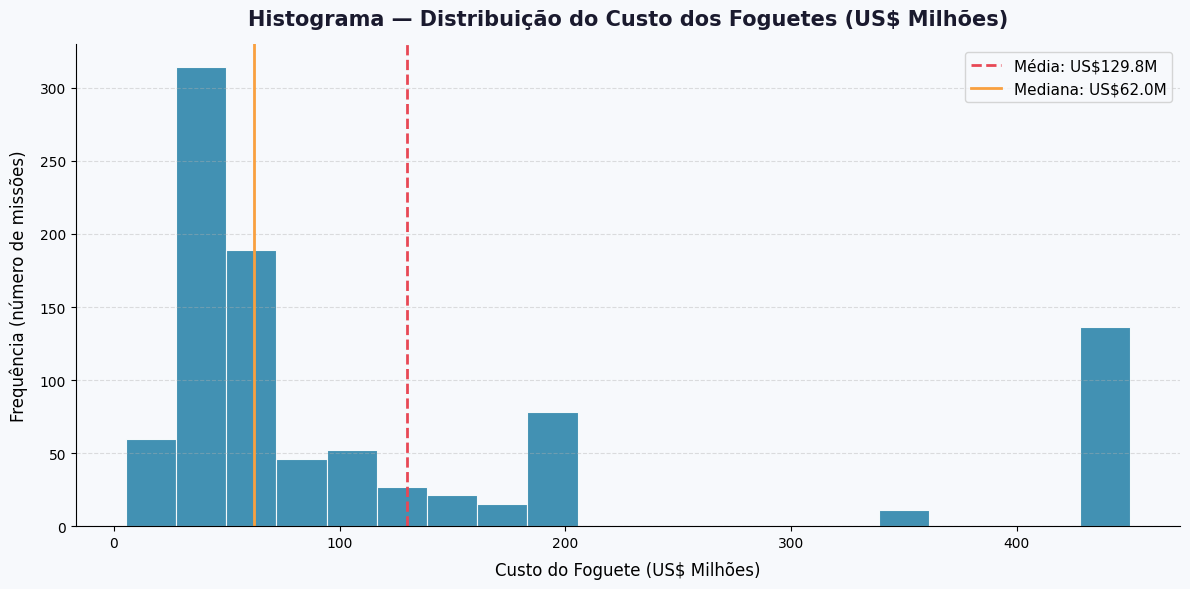

✓ Gráfico 1 salvo.


In [7]:
custo_valido = df['custo_milhoes'].dropna()

fig, ax = plt.subplots(figsize=(12, 6))

n, bins_h, patches = ax.hist(
    custo_valido, bins=20,
    color='#2E86AB', edgecolor='white', linewidth=0.8, alpha=0.9
)

# Linha da média e mediana
ax.axvline(custo_valido.mean(),   color='#E84855', linewidth=2,
           linestyle='--', label=f'Média: US${custo_valido.mean():.1f}M')
ax.axvline(custo_valido.median(), color='#F9A03F', linewidth=2,
           linestyle='-',  label=f'Mediana: US${custo_valido.median():.1f}M')

# Títulos e eixos (obrigatórios)
ax.set_title(
    'Histograma — Distribuição do Custo dos Foguetes (US$ Milhões)',
    fontsize=15, fontweight='bold', pad=14, color='#1A1A2E'
)
ax.set_xlabel('Custo do Foguete (US$ Milhões)', fontsize=12, labelpad=8)
ax.set_ylabel('Frequência (número de missões)', fontsize=12, labelpad=8)

# Legenda (obrigatória)
ax.legend(fontsize=11, framealpha=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('grafico1_histograma_custo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfico 1 salvo.')

**📌 Interpretação:**  
O histograma evidencia forte **assimetria à direita**: a maioria das missões tem custo baixo (abaixo de US$100M), enquanto uma minoria de missões caras estica a distribuição para a direita. A média (US$129,8M) está bem acima da mediana (US$62M), confirmando essa assimetria.

## Gráfico 2 — Barras: Número de Lançamentos por País (Top 8)
**Tipo:** Gráfico de barras  
**Variável:** País de lançamento

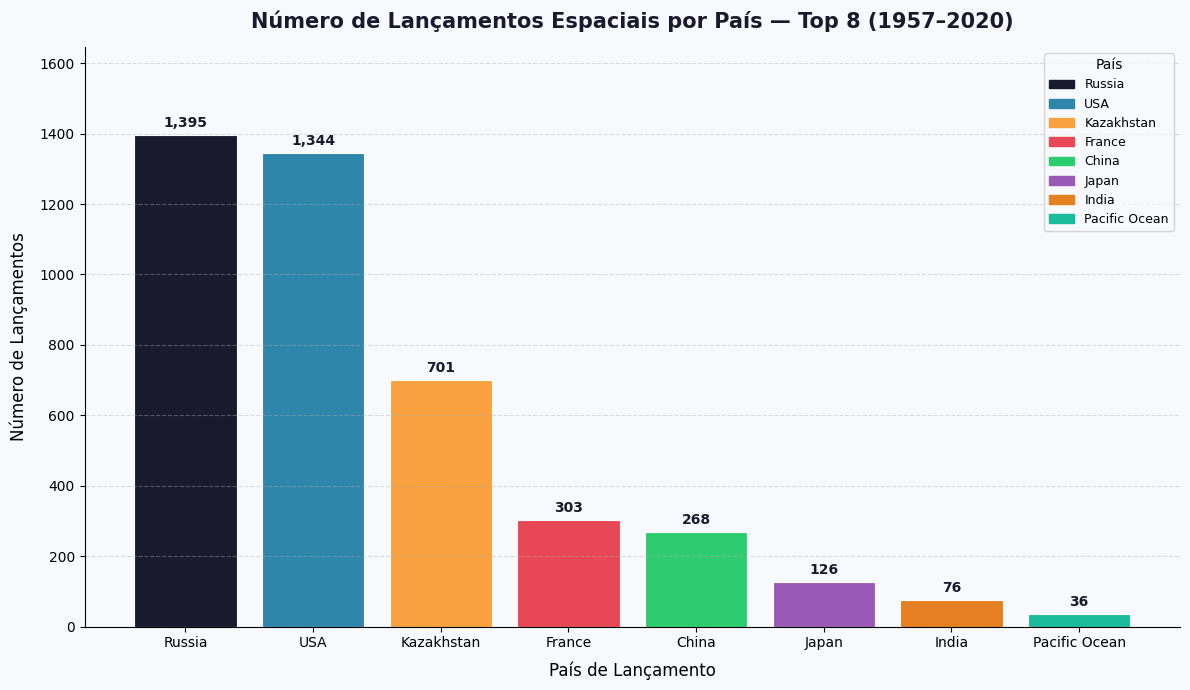

✓ Gráfico 2 salvo.


In [8]:
# Top 8 países por número de lançamentos
top_paises = df['pais'].value_counts().head(8)

# Paleta de cores diferenciada
cores_paises = ['#1A1A2E','#2E86AB','#F9A03F','#E84855',
                '#2ECC71','#9B59B6','#E67E22','#1ABC9C']

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    top_paises.index, top_paises.values,
    color=cores_paises, edgecolor='white', linewidth=0.8
)

# Rótulo de valor em cima de cada barra
for bar, val in zip(bars, top_paises.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'{val:,}', ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#1A1A2E'
    )

# Títulos e eixos (obrigatórios)
ax.set_title(
    'Número de Lançamentos Espaciais por País — Top 8 (1957–2020)',
    fontsize=15, fontweight='bold', pad=14, color='#1A1A2E'
)
ax.set_xlabel('País de Lançamento', fontsize=12, labelpad=8)
ax.set_ylabel('Número de Lançamentos', fontsize=12, labelpad=8)

# Legenda com cores por país
legenda = [mpatches.Patch(color=c, label=p)
           for c, p in zip(cores_paises, top_paises.index)]
ax.legend(handles=legenda, title='País', fontsize=9,
          loc='upper right', framealpha=0.8)

ax.set_ylim(0, top_paises.max() * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig('grafico2_barras_pais.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfico 2 salvo.')

**📌 Interpretação:**  
**Rússia** (1.395) e **EUA** (1.344) dominam amplamente o histórico de lançamentos, juntos representando quase **64%** do total. O **Cazaquistão** aparece em 3º lugar por sediar o Cosmódromo de Baikonur, base de lançamento da Roscosmos russa. **China** (268) e **França** (303, via Arianespace) completam os grandes players do mercado.

---
# ETAPA 4 — Estatística Descritiva (Análises Univariadas)
> **Valor: 2,0 pontos**

## 4.1 Variável 1: Custo do Foguete (US$ Milhões)

In [9]:
custo = df['custo_milhoes'].dropna()

# ── Medidas de Tendência Central ──────────────────────────────────────────
media   = custo.mean()
mediana = custo.median()
moda    = stats.mode(custo, keepdims=True).mode[0]

# ── Medidas de Dispersão ─────────────────────────────────────────────────
vmin      = custo.min()
vmax      = custo.max()
amplitude = vmax - vmin
variancia = custo.var()
desvio    = custo.std()

# ── Medidas Separatrizes (Quartis) ────────────────────────────────────────
q1  = custo.quantile(0.25)
q2  = custo.quantile(0.50)
q3  = custo.quantile(0.75)
iqr = q3 - q1

# ── Exibição organizada ───────────────────────────────────────────────────
resultado1 = pd.DataFrame({
    'Medida': [
        '── TENDÊNCIA CENTRAL ──', 'Média', 'Mediana', 'Moda',
        '── DISPERSÃO ──', 'Valor Mínimo', 'Valor Máximo',
        'Amplitude', 'Variância', 'Desvio Padrão',
        '── SEPARATRIZES ──', 'Q1 (25%)', 'Q2 — Mediana (50%)',
        'Q3 (75%)', 'IIQ (Q3 – Q1)'
    ],
    'Valor (US$ M)': [
        '', round(media,2), round(mediana,2), round(moda,2),
        '', round(vmin,2), round(vmax,2),
        round(amplitude,2), round(variancia,2), round(desvio,2),
        '', round(q1,2), round(q2,2),
        round(q3,2), round(iqr,2)
    ]
})

print(f'N válido: {len(custo)} missões com custo informado')
print('─' * 45)
resultado1

N válido: 949 missões com custo informado
─────────────────────────────────────────────


,Medida,Valor (US$ M)
0,── TENDÊNCIA CENTRAL ──,
1,Média,129.8
2,Mediana,62.0
3,Moda,450.0
4,── DISPERSÃO ──,
5,Valor Mínimo,5.3
6,Valor Máximo,450.0
7,Amplitude,444.7
8,Variância,20512.06
9,Desvio Padrão,143.22


**📌 Interpretação:**  
A **média de US$129,80M** está muito acima da **mediana de US$62,00M**, indicando forte **assimetria positiva (à direita)**: poucas missões extremamente caras distorcem a média. O **desvio padrão de US$143,22M** — superior à própria média — confirma enorme dispersão nos custos.  

Os quartis mostram que **50% das missões custaram entre US$40M (Q1) e US$164M (Q3)**. Para fins de planejamento orçamentário, a **mediana (US$62M) é o indicador mais confiável** do custo típico de um lançamento, pois não é influenciada pelos valores extremos.

## 4.2 Variável 2: Ano de Lançamento

In [10]:
ano_serie = df['ano'].dropna().astype(float)

# ── Medidas de Tendência Central ──────────────────────────────────────────
media_a   = ano_serie.mean()
mediana_a = ano_serie.median()
moda_a    = stats.mode(ano_serie, keepdims=True).mode[0]

# ── Medidas de Dispersão ─────────────────────────────────────────────────
vmin_a      = ano_serie.min()
vmax_a      = ano_serie.max()
amplitude_a = vmax_a - vmin_a
variancia_a = ano_serie.var()
desvio_a    = ano_serie.std()

# ── Medidas Separatrizes ─────────────────────────────────────────────────
q1_a  = ano_serie.quantile(0.25)
q2_a  = ano_serie.quantile(0.50)
q3_a  = ano_serie.quantile(0.75)
iqr_a = q3_a - q1_a

resultado2 = pd.DataFrame({
    'Medida': [
        '── TENDÊNCIA CENTRAL ──', 'Média', 'Mediana', 'Moda',
        '── DISPERSÃO ──', 'Valor Mínimo', 'Valor Máximo',
        'Amplitude', 'Variância', 'Desvio Padrão',
        '── SEPARATRIZES ──', 'Q1 (25%)', 'Q2 — Mediana (50%)',
        'Q3 (75%)', 'IIQ (Q3 – Q1)'
    ],
    'Valor (Ano)': [
        '', round(media_a,1), int(mediana_a), int(moda_a),
        '', int(vmin_a), int(vmax_a),
        f'{int(amplitude_a)} anos', round(variancia_a,2), round(desvio_a,2),
        '', int(q1_a), int(q2_a),
        int(q3_a), f'{int(iqr_a)} anos'
    ]
})

print(f'N válido: {len(ano_serie)} registros')
print('─' * 45)
resultado2

N válido: 4198 registros
─────────────────────────────────────────────


,Medida,Valor (Ano)
0,── TENDÊNCIA CENTRAL ──,
1,Média,1987.5
2,Mediana,1985
3,Moda,2018
4,── DISPERSÃO ──,
5,Valor Mínimo,1957
6,Valor Máximo,2020
7,Amplitude,63 anos
8,Variância,327.08
9,Desvio Padrão,18.09


**📌 Interpretação:**  
A **mediana em 1985** revela que metade de toda a atividade espacial humana ocorreu durante a Guerra Fria. A **moda em 2018** indica que este foi o ano com o maior número de lançamentos individuais — marcando o auge da era SpaceX, com o Falcon 9 realizando dezenas de lançamentos reutilizáveis.  

A **amplitude de 63 anos** cobre desde o Sputnik (1957) até 2020. O **IIQ de 30 anos** (1972 a 2002) delimita o núcleo histórico da corrida espacial. A proximidade entre média (1987) e mediana (1985) indica distribuição relativamente simétrica ao longo do tempo.

---
# ETAPA 5 — Conclusões e Insights Estratégicos
> **Valor: 2,0 pontos** — (esta seção complementa o Relatório PDF)

## O que os dados mostram?

A análise estatística do dataset de missões espaciais revela **três eras históricas** com características distintas:

| Era | Período | Lançamentos | Característica |
|---|---|---|---|
| Guerra Fria | 1957–1989 | 2.387 (56,9%) | Domínio governamental EUA/URSS |
| Pós-Guerra Fria | 1990–2009 | 1.091 (26,0%) | Cooperação internacional (ISS) |
| Nova Economia | 2010–2020 | 720 (17,1%) | Ascensão do setor privado |

## Como podem ajudar na tomada de decisão?

| # | Insight | Dado Estatístico |
|---|---|---|
| 1 | **A mediana é o melhor referencial de custo** — use US$62M para planejamento, não a média | Média US$130M vs Mediana US$62M |
| 2 | **Taxa de sucesso superior a 89%** — risco operacional gerenciável com seguro e redundância | 3.879 de 4.324 missões bem-sucedidas |
| 3 | **2018 foi o pico histórico** — o mercado está crescendo e a janela está aberta | Moda = 2018; tendência ascendente |
| 4 | **Mercado é bimodal**: estratégias de nicho (barato ou premium) têm mais sucesso | Classes 0–50M e 350–450M dominam |
| 5 | **Rússia e EUA dominam** — novos entrantes têm espaço nos segmentos emergentes | Russia 1.395 + EUA 1.344 = 64% do total |

## Relação com a Global Solution

O tema da Global Solution — Nova Economia Espacial — está diretamente conectado a estes dados. A virada que aconteceu a partir de 2010, com a queda de custos (Falcon 9 reutilizável) e aumento de lançamentos privados, abre oportunidades em satélites de monitoramento ambiental, internet via satélite, sensoriamento remoto e logística orbital — exatamente os segmentos que empresas inovadoras podem explorar usando os padrões revelados por esta análise.

---
*Análise produzida com Python (pandas, numpy, matplotlib, scipy) | Base: All Space Missions from 1957 — Kaggle | Global Solution — Estatística e Análise de Dados*